In [1]:
from pathlib import Path

import h5py as h5
import numpy as np

import matplotlib.pyplot as plt
from structure_tensor import structure_tensor_3d, eig_special_3d
from structure_tensor.st3d import eigh_baseline_3d, S6_to_mat33
from structure_tensor.h5_io import load_h5_datasets
from structure_tensor.metrics import metric_mse, metric_rmse, cosine_similarity

from structure_tensor.post_processing import align_direction
from structure_tensor.pre_processing import normalize



In [2]:
file_path = Path("../data2/original/285_01_HR_.vol.sub.h5")


file_out_path = Path("../data2/original/285_01_HR_.vol.tiny.h5")


with h5.File(file_path,"r") as F:
    vol = F["volume"][:128,:128,:128]

    with h5.File(file_out_path,"w") as Fout:
        Fout.create_dataset("volume",data=vol,compression="gzip")

In [3]:
keys = ["volume"]

slices = {
    "volume": (slice(0,10), slice(0,512), slice(0,512)),
}

data = load_h5_datasets(file_path, keys, slices=slices)

for key in keys:
    tmp = data.get(key)
    if tmp is not None:
        print(
    f"{key}:\n"
    f"  dtype : {tmp.dtype}\n"
    f"  min   : {tmp.min():.6g}\n"
    f"  max   : {tmp.max():.6g}\n"
    f"  shape : {tmp.shape}\n"
)

Available keys: ['volume']
volume:
  dtype : float32
  min   : 2989
  max   : 59810
  shape : (10, 512, 512)



In [4]:
vol_norm = normalize(data["volume"],method='robust')

print(vol_norm.dtype,vol_norm.min(),vol_norm.max(),vol_norm.shape)

float32 0.0 1.0 (10, 512, 512)


In [5]:
## Scan Parameters
voxel_size = 0.00230760 # voxel size in µm/Px
## Material Parameters
fiber_diameter = 7.e-3 # fiber diameter in µm

## set parameters for Gaussian Kernel
r = fiber_diameter / 2 / voxel_size
sigma = round(np.sqrt(r**2 / 2), 2)
rho = 4 * sigma

print(f"sigma: {sigma:.3f}, rho: {rho:.3f}")

sigma: 1.070, rho: 4.280


In [6]:
## Compute Structrue tensor
S = structure_tensor_3d(vol_norm, sigma, rho)
S_ = S6_to_mat33(S)
print(f'Structure tensor: {S.shape} array as type {S.dtype}.')
print(f'Full Structure tensor: {S_.shape} array as type {S_.dtype}.')

Structure tensor: (6, 10, 512, 512) array as type float32.
Full Structure tensor: (10, 512, 512, 3, 3) array as type float32.


In [7]:
## eig_special_3d analytical implementation

_ , vec1 = eig_special_3d(S, full=False)
print(f'Orientation: {vec1.shape} array as type {vec1.dtype}')
print(vec1[:,0,0,0])

Orientation: (3, 10, 512, 512) array as type float32
[0.77948266 0.05175645 0.6242821 ]


In [8]:
_, vec2 = eigh_baseline_3d(S_, full=False)
print(f'Orientation: {vec2.shape} array as type {vec2.dtype}')
print(vec1[:,0,0,0])

Orientation: (3, 10, 512, 512) array as type float32
[0.77948266 0.05175645 0.6242821 ]


In [9]:
axes = ("x","y","z")

vec1 = align_direction(vec1, axes=axes)
vec2 = align_direction(vec2, axes=axes)



In [ ]:
print(vec1[:,0,0,0],vec2[:,0,0,0])

In [10]:
# cosine similarity on full 3D vectors
mean_cos, min_cos, max_ang = cosine_similarity(vec1, vec2)
print("cos:", mean_cos, min_cos, max_ang)

# MSE/RMSE comparing the transformed vec__ to vec
mse = metric_mse(vec1, vec2)
rmse = metric_rmse(vec1, vec2)
print("mse/rmse:", mse, rmse)

cos: 0.9999987483024597 -0.8557953834533691 148.8477020263672
mse/rmse: 8.492383472002984e-07 0.0009215413010679185


In [11]:
def worst_voxels(vec1, vec2, k=10, eps=1e-12):
    # normalize both
    a = vec1 / (np.linalg.norm(vec1, axis=0, keepdims=True) + eps)
    b = vec2/ (np.linalg.norm(vec2, axis=0, keepdims=True) + eps)

    cos = np.sum(a*b, axis=0)  # (X,Y,Z)

    # flatten indices of smallest cos
    flat = np.argsort(cos.ravel())[:k]
    idx = np.array(np.unravel_index(flat, cos.shape)).T  # k x 3 -> (x,y,z)
    return cos, idx

cos, idx = worst_voxels(vec1, vec2, k=20)
print("Worst 10 cosine values:")
for (x,y,z) in idx:
    print(
        f"Voxel (x={x}, y={y}, z={z})\n"
        f"  cos  : {float(cos[x, y, z]):.6f}\n"
        f"  vec1 : {vec1[:, x, y, z]}\n"
        f"  vec2 : {vec2[:, x, y, z]}\n"
    )

Worst 10 cosine values:
Voxel (x=8, y=391, z=336)
  cos  : -0.855795
  vec1 : [-0.04900321  0.8830629  -0.46668884]
  vec2 : [ 0.04817613 -0.5137527   0.8565846 ]

Voxel (x=1, y=454, z=363)
  cos  : 0.636909
  vec1 : [-6.575162e-01  7.534403e-01 -1.305711e-04]
  vec2 : [1.6207846e-01 9.8677790e-01 2.7018687e-05]

Voxel (x=8, y=233, z=306)
  cos  : 0.744949
  vec1 : [ 5.4844153e-01 -7.2846946e-05  8.3618885e-01]
  vec2 : [-1.4927851e-01  1.7508117e-05  9.8879516e-01]

Voxel (x=3, y=317, z=121)
  cos  : 0.845059
  vec1 : [-7.784560e-06  8.357826e-01  5.490605e-01]
  vec2 : [-2.4528583e-07  9.9985349e-01  1.7118359e-02]

Voxel (x=1, y=80, z=212)
  cos  : 0.868600
  vec1 : [-1.304545e-01  9.914543e-01  8.368202e-08]
  vec2 : [ 3.7796688e-01  9.2581910e-01 -1.9411613e-07]

Voxel (x=3, y=448, z=363)
  cos  : 0.921561
  vec1 : [-5.0152677e-05  9.9901378e-01  4.4400610e-02]
  vec2 : [-4.0379629e-04  9.0341419e-01  4.2876878e-01]

Voxel (x=4, y=192, z=297)
  cos  : 0.940888
  vec1 : [-9.1792517

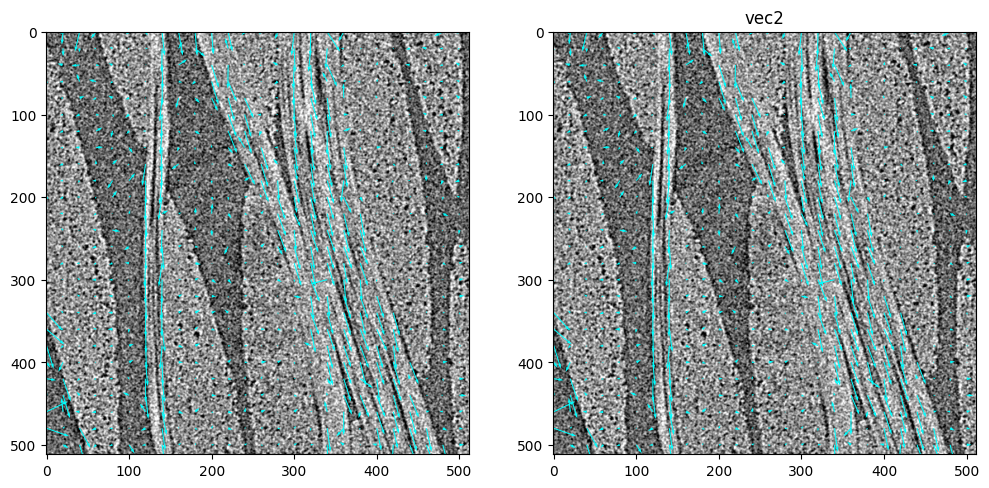

In [12]:
slice_idx = 3

fig, axs = plt.subplots(1,2, figsize=(12,6))

# background
img = vol_norm[slice_idx]

# vector components (choose in-plane components)
v1y = vec1[1, slice_idx]
v1x = vec1[0, slice_idx]

# vector components (choose in-plane components)
v2y = vec2[1, slice_idx]
v2x = vec2[0, slice_idx]

# subsample so arrows are readable
step = 20
Y, X = np.mgrid[0:img.shape[0]:step, 0:img.shape[1]:step]

axs[0].imshow(img, cmap="gray")
axs[0].quiver(
    X, Y,
    v1x[::step, ::step],
    v1y[::step, ::step],
    color="cyan",
    angles="xy",
    scale_units="xy",
    scale=None
)
axs[1].set_title("vec_1")



axs[1].imshow(img, cmap="gray")
axs[1].quiver(
    X, Y,
    v2x[::step, ::step],
    v2y[::step, ::step],
    color="cyan",
    angles="xy",
    scale_units="xy",
    scale=None
)
axs[1].set_title("vec2")

plt.show()

MSE  (slice 3): 1.707066e-07
RMSE (slice 3): 4.131665e-04
Cosine mean : 0.999985
Cosine min  : -1.000000
Max angle   : 180.000 deg


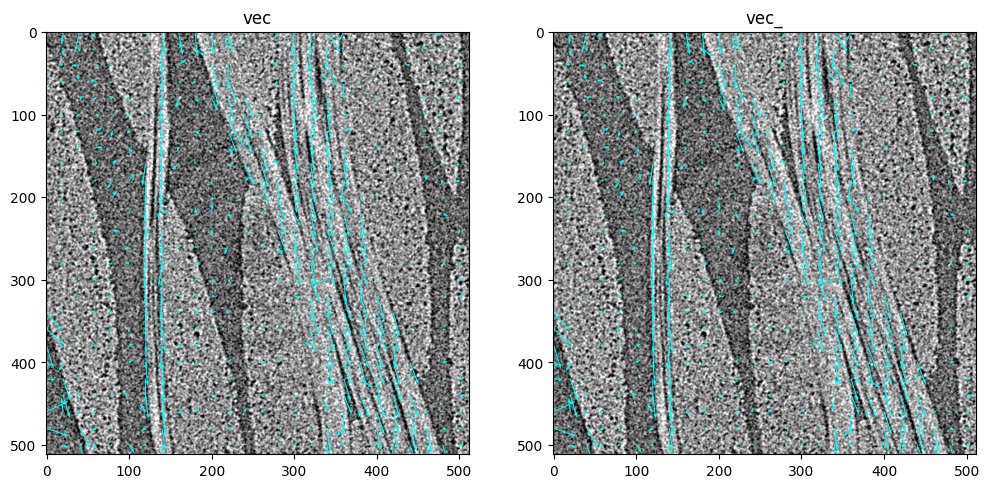

In [14]:
slice_idx = 3

fig, axs = plt.subplots(1,2, figsize=(12,6))

# background
img = vol_norm[slice_idx]



# vector components (choose in-plane components)
v1y = vec1[1, slice_idx]   # Y component
v1x = vec1[0, slice_idx]   # X component

v2y = vec2[1, slice_idx]
v2x = vec2[0, slice_idx]


# -----------------------------------
# Build 2D vector fields for metrics
# -----------------------------------
vec1_slice  = np.stack([v1x,  v1y],  axis=0)   # (2, H, W)
vec_slice2 = np.stack([v2x, v2y], axis=0)   # (2, H, W)

# -----------------------------------
# MSE / RMSE
# -----------------------------------
mse  = metric_mse(vec1_slice, vec_slice2)
rmse = metric_rmse(vec1_slice, vec_slice2)

print(f"MSE  (slice {slice_idx}): {mse:.6e}")
print(f"RMSE (slice {slice_idx}): {rmse:.6e}")

# -----------------------------------
# Cosine similarity (signed)
# -----------------------------------
mean_cos, min_cos, max_ang = cosine_similarity(
    vec1_slice,
    vec_slice2,
    axis=0,                # vector components axis
    sign_invariant=False   # set True if eigenvector ambiguity
)

print(f"Cosine mean : {mean_cos:.6f}")
print(f"Cosine min  : {min_cos:.6f}")
print(f"Max angle   : {max_ang:.3f} deg")


# subsample so arrows are readable
step = 20
Y, X = np.mgrid[0:img.shape[0]:step, 0:img.shape[1]:step]

axs[0].imshow(img, cmap="gray")
axs[0].quiver(
    X, Y,
    v1x[::step, ::step],
    v1y[::step, ::step],
    color="cyan",
    angles="xy",
    scale_units="xy",
    scale=None
)
axs[0].set_title("vec")

axs[1].imshow(img, cmap="gray")
axs[1].quiver(
    X, Y,
    v2x[::step, ::step],
    v2y[::step, ::step],
    color="cyan",
    angles="xy",
    scale_units="xy",
    scale=None
)
axs[1].set_title("vec_")

plt.show()




In [15]:
def edge_aware_smooth_vec(v, iters=2, sigma_theta_deg=24.0, eps=1e-12):
    """
    Edge-aware smoothing for a line field (v ≡ -v). Preserves 90° jumps.
    v: (3,X,Y,Z)
    """
    v = v.copy()
    sigma_theta = np.deg2rad(sigma_theta_deg)

    def normed(x):
        n = np.linalg.norm(x, axis=0, keepdims=True)
        return x / (np.maximum(n, eps))

    v = normed(v)

    # 6-neighborhood shifts
    shifts = [(+1,0,0),(-1,0,0),(0,+1,0),(0,-1,0),(0,0,+1),(0,0,-1)]

    for _ in range(iters):
        acc = np.zeros_like(v)
        wsum = np.zeros(v.shape[1:], dtype=v.dtype)

        for dx,dy,dz in shifts:
            vn = np.roll(v, shift=(dx,dy,dz), axis=(1,2,3))

            # sign-invariant angle via abs(dot)
            c = np.abs(np.sum(v * vn, axis=0))
            c = np.clip(c, 0.0, 1.0)
            theta = np.arccos(c)

            w = np.exp(-(theta*theta) / (2*sigma_theta*sigma_theta)).astype(v.dtype)

            acc += vn * w[None, ...]
            wsum += w

        # include self weight
        acc += v
        wsum += 1.0

        v = acc / wsum[None, ...]
        v = normed(v)

    return v

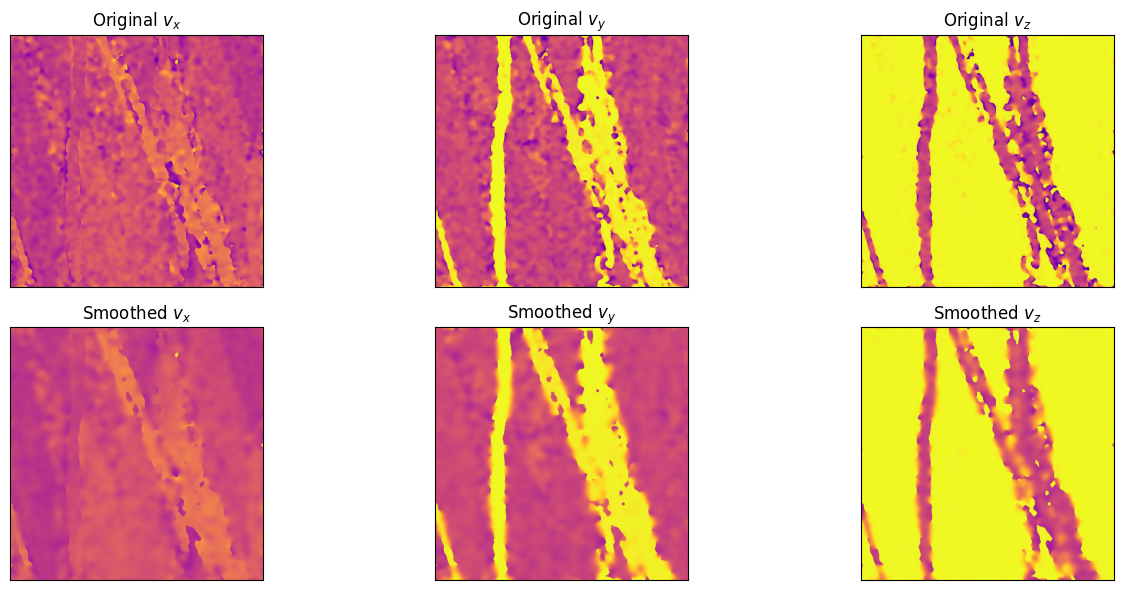

In [16]:
vec_smoothed = edge_aware_smooth_vec(vec1,iters=100,sigma_theta_deg=24)

slice_idx = 0  # slice in X-direction

fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True)

# ---------------------------
# Original vector components
# ---------------------------
axs[0,0].imshow(vec1[0, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[0,0].set_title("Original $v_x$")

axs[0,1].imshow(vec1[1, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[0,1].set_title("Original $v_y$")

axs[0,2].imshow(vec1[2, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[0,2].set_title("Original $v_z$")

# ---------------------------
# Smoothed vector components
# ---------------------------
axs[1,0].imshow(vec_smoothed[0, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[1,0].set_title("Smoothed $v_x$")

axs[1,1].imshow(vec_smoothed[1, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[1,1].set_title("Smoothed $v_y$")

axs[1,2].imshow(vec_smoothed[2, slice_idx], cmap="plasma",vmin=-1,vmax=1)
axs[1,2].set_title("Smoothed $v_z$")

# Cosmetic improvements
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
def debug_first_vectors(vec, vec__, n=20, y=0, z=0):
    print(f"Checking first {n} vectors at y={y}, z={z}\n")

    for x in range(min(n, vec.shape[1])):
        v  = vec[:, x, y, z]
        v_ = vec__[:, x, y, z]

        dot = np.dot(v, v_)
        norm_v  = np.linalg.norm(v)
        norm_v_ = np.linalg.norm(v_)

        cos = dot / (norm_v * norm_v_ + 1e-12)

        print(f"x = {x}")
        print(f"  vec1   = {v[0]:.3f},{v[1]:.3f},{v[2]:.3f}")
        print(f"  vec2   = {v_[0]:.3f},{v_[1]:.3f},{v_[2]:.3f}")
        print(f"  dot   = {dot:.6f}")
        print(f"  cos   = {cos:.6f}")

        # check sign flip
        if np.allclose(v, -v_, atol=1e-6):
            print("  -> pure sign flip")

        # check component permutation
        for perm in [(0,1,2),(0,2,1),(1,0,2),(1,2,0),(2,0,1),(2,1,0)]:
            if np.allclose(v, v_[list(perm)], atol=1e-6):
                print(f"  -> component permutation {perm}")

        print("-" * 40)

In [ ]:
debug_first_vectors(vec1, vec2)

In [ ]:
def align_to_other(v, v_ref, lib=np, inplace=False):
    """
    Flip v where dot(v, v_ref) < 0 so it matches v_ref's sign convention.
    v, v_ref: (..., 3) unit vectors
    """
    if not inplace:
        v = v.copy()
    dot = (v * v_ref).sum(axis=-1)
    flip = dot < 0
    v[flip] *= -1
    return v

In [ ]:
out_path = file_path.with_name(
    file_path.name.replace("..vol.vec.gzip.test.h5", ".vol.vec.gzip.test.results.h5")
)

print(out_path)